In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# Define the path to the zip file
zip_file_path = "/content/netflix dataset.zip"
# Define the directory where to extract the contents
extract_dir = "/content/netflix_data"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
print(f"Unzipping {zip_file_path} to {extract_dir}...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Unzipping complete.")

# List files in the extracted directory to find the CSV
extracted_files = os.listdir(extract_dir)
print("Files extracted:", extracted_files)

# Assuming the CSV file is named 'netflix_titles.csv' within the extracted directory
# If not, you might need to adjust this path based on the 'Files extracted' output
csv_file_name = "netflix_titles.csv" # Common name, might need adjustment
csv_path = os.path.join(extract_dir, csv_file_name)

# Check if the CSV file actually exists in the extracted path before reading
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("DataFrame loaded successfully. Displaying head:")
    df.head()
else:
    print(f"Error: CSV file '{csv_file_name}' not found in '{extract_dir}'.")
    print("Please check the extracted files listed above and adjust 'csv_file_name' if necessary.")

Unzipping /content/netflix dataset.zip to /content/netflix_data...
Unzipping complete.
Files extracted: ['netflix_titles.csv']
DataFrame loaded successfully. Displaying head:


In [6]:
# check shape and basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (8807, 12)

Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [8]:
# Fill missing values instead of deleting rows
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop the few missing rows in rating & duration
df.dropna(subset=['rating', 'duration', 'date_added'], inplace=True)

# Extract year from date_added
# Strip whitespace and then convert to datetime, coercing errors to NaT
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added'].dt.year

print("Cleaning done! New shape:", df.shape)
print("Missing values remaining:\n", df.isnull().sum())

Cleaning done! New shape: (8790, 13)
Missing values remaining:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64


/tmp/ipykernel_13374/1642054582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


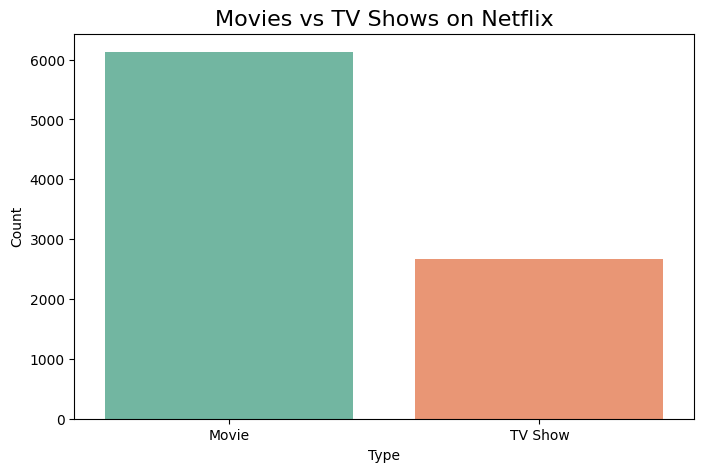

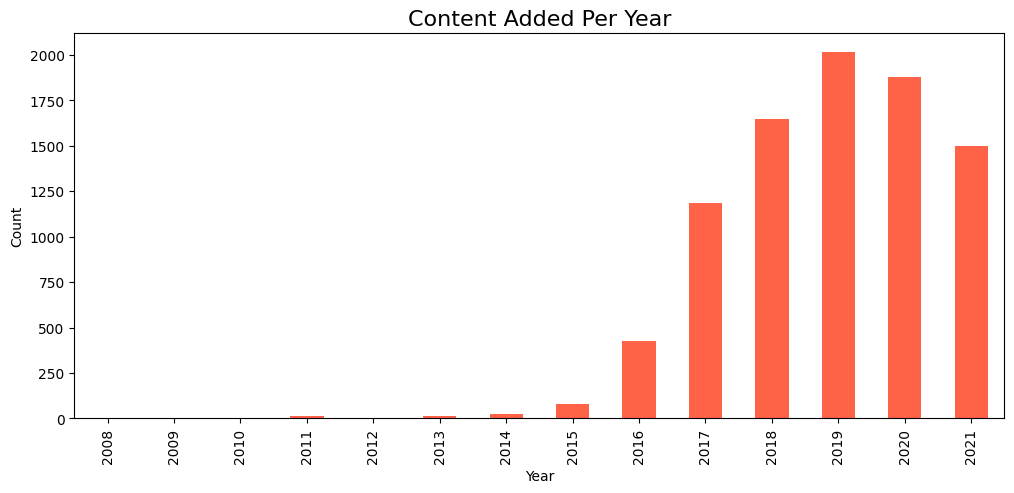

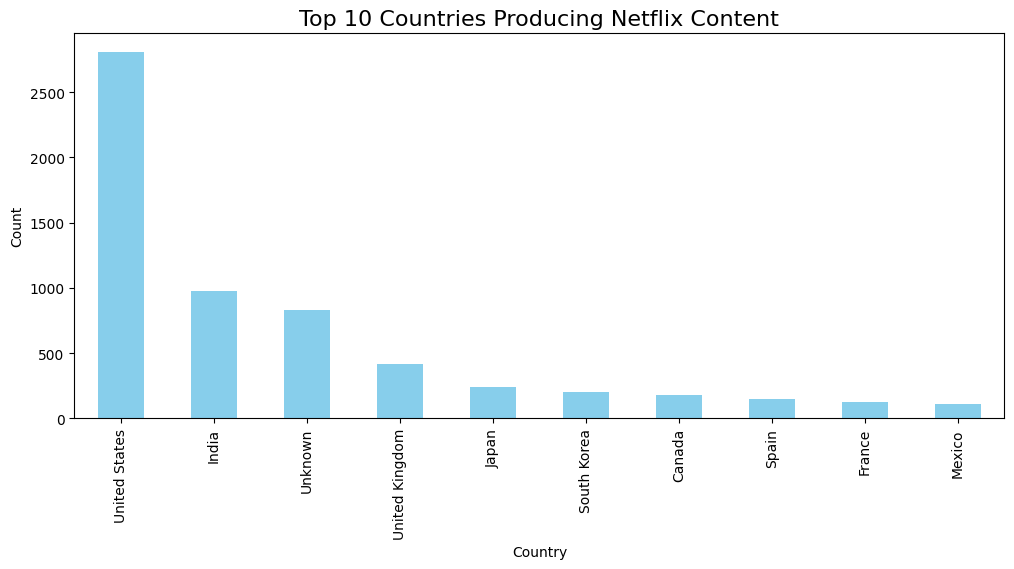

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df, palette='Set2')
plt.title("Movies vs TV Shows on Netflix", fontsize=16)
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()
# Second Chart — Content Added Per Year
plt.figure(figsize=(12,5))
df['year_added'].value_counts().sort_index().plot(kind='bar', color='tomato')
plt.title("Content Added Per Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()
# Third Chart — Top 10 Countries
plt.figure(figsize=(12,5))
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar', color='skyblue')
plt.title("Top 10 Countries Producing Netflix Content", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

After Movies vs TV Shows chart write:
"Netflix has more Movies than TV Shows. Movies make up approximately 70% of total content."
After Content Per Year chart write:
"Netflix content additions grew rapidly between 2015-2019. Content dropped after 2020 possibly due to COVID-19."
After Top 10 Countries chart write:
"The United States produces the most Netflix content followed by India and United Kingdom."

/tmp/ipykernel_13374/2767040041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating', data=df,


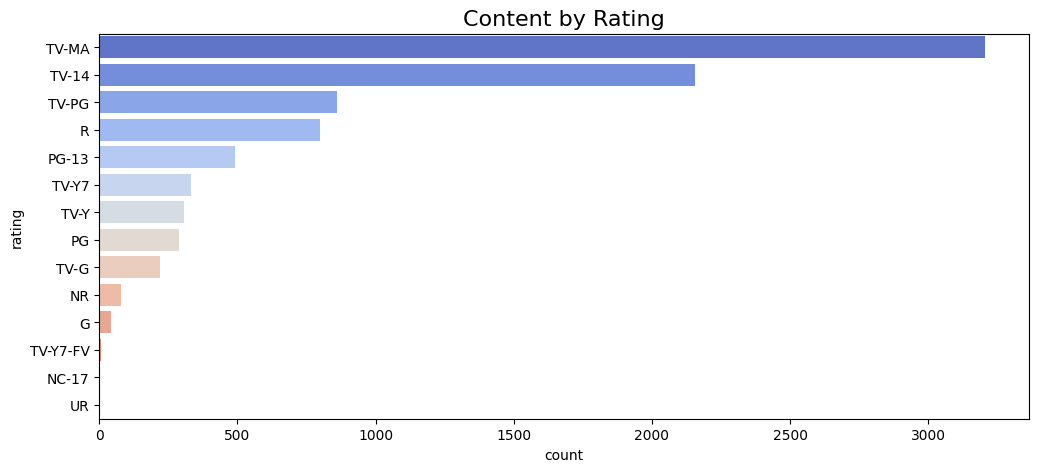

In [11]:
plt.figure(figsize=(12,5))
sns.countplot(y='rating', data=df,
              order=df['rating'].value_counts().index,
              palette='coolwarm')
plt.title("Content by Rating", fontsize=16)
plt.show()

## 🔍 Key Insights from Netflix Data Analysis

1. **Movies vs TV Shows:** Netflix has more Movies (~70%)
   than TV Shows (~30%).

2. **Growth Trend:** Content additions peaked in 2019.
   There was a drop after 2020 due to COVID-19.

3. **Top Country:** USA produces the most Netflix content,
   followed by India and UK.

4. **Rating:** TV-MA and TV-14 are the most common ratings,
   meaning most content targets adults.

5. **Conclusion:** Netflix heavily focuses on Movies and
   adult-oriented content, with USA dominating production.